In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
train_data=pd.read_csv("../data/processed/train_data.csv")
test_data=pd.read_csv("../data/processed/test_data.csv")

In [3]:
baseline_predictions=test_data["rolling_7_quantity"]

baseline_mae=mean_absolute_error(test_data["daily_quantity"],baseline_predictions)
baseline_rmse=np.sqrt(mean_squared_error(test_data["daily_quantity"],baseline_predictions))
baseline_r2=r2_score(test_data["daily_quantity"],baseline_predictions)
print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 1.0987187455066552
Baseline RMSE: 1.5396418524327629
Baseline R²  : 0.6077670837469287


# lets start with Linear Regression

In [4]:
numeric_features=["store_id","sku_id","year","month","day_of_week","lag_1_quantity","lag_7_quantity","rolling_7_quantity","is_weekend"]

X_train_lr=train_data[numeric_features]
X_test_lr=test_data[numeric_features]

y_train_lr=train_data["daily_quantity"]
y_test_lr=test_data["daily_quantity"]

print("X_train:",X_train_lr.shape)
print("X_test:",X_test_lr.shape)

X_train: (6246038, 9)
X_test: (2267573, 9)


In [5]:
print("Unique stores:", train_data["store_id"].nunique())
print("Unique SKUs:", train_data["sku_id"].nunique())
print("Unique categories:", train_data["category"].nunique())
print("Unique brands:", train_data["brand"].nunique())
print("Unique store cities:", train_data["store_city"].nunique())
print("Unique store types:", train_data["store_type"].nunique())

Unique stores: 30
Unique SKUs: 5000
Unique categories: 12
Unique brands: 30
Unique store cities: 12
Unique store types: 4


In [6]:
categorical_features = [
    "store_id",
    "sku_id",
    "category",
    "brand",
    "store_city",
    "store_type"
]

numeric_features = [
    "year",
    "month",
    "day_of_week",
    "lag_1_quantity",
    "lag_7_quantity",
    "rolling_7_quantity",
    "is_weekend"
]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['store_id', 'sku_id', 'category', 'brand', 'store_city', 'store_type']
Numeric features: ['year', 'month', 'day_of_week', 'lag_1_quantity', 'lag_7_quantity', 'rolling_7_quantity', 'is_weekend']


In [7]:
# encode sku_id and other columns
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)
X_train_cat=encoder.fit_transform(train_data[categorical_features] )
X_test_cat=encoder.fit_transform(test_data[categorical_features] )

print("Training categorical matrix:", X_train_cat.shape)
print("Test categorical matrix:", X_test_cat.shape)

Training categorical matrix: (6246038, 5088)
Test categorical matrix: (2267573, 5088)


In [8]:
from scipy.sparse import hstack
X_train_lr_final=hstack([X_train_cat,train_data[numeric_features].values])
X_test_lr_final=hstack([X_test_cat,test_data[numeric_features].values])

print("Final X_train shape:", X_train_lr_final.shape)
print("Final X_test shape:", X_test_lr_final.shape)

Final X_train shape: (6246038, 5095)
Final X_test shape: (2267573, 5095)


In [9]:
from sklearn.linear_model import LinearRegression

In [10]:
lr_model=LinearRegression()

lr_model.fit(X_train_lr_final,y_train_lr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5095,)","[-0. ,-0.04, 0. ,...,-0.02, 0.42, 0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.67
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5095


In [11]:
lr_predictions=lr_model.predict(X_test_lr_final)

print("Number of predictions:", len(lr_predictions))
print("First 10 predictions:", lr_predictions[:10])

Number of predictions: 2267573
First 10 predictions: [2.14337769 2.02256416 1.96112812 1.96149424 1.78120199 1.77887855
 1.71607061 1.65732413 1.59689433 1.77575951]


In [12]:
# comparison time
lr_mae=mean_absolute_error(y_test_lr,lr_predictions)

lr_rmse=np.sqrt(mean_squared_error(y_test_lr,lr_predictions))

lr_r2=r2_score(y_test_lr,lr_predictions)

print("Linear Regression MAE : ",lr_mae)
print("Linear Regression RMSE : ",lr_rmse)
print("Linear Regression r2 : ",lr_r2)

Linear Regression MAE :  1.0487946938044037
Linear Regression RMSE :  1.4992323701852772
Linear Regression r2 :  0.6280860042870535


# So ya linear Regression works fine 

In [13]:
import importlib.util

print("LightGBM installed:", importlib.util.find_spec("lightgbm") is not None)

LightGBM installed: True


# we will go with LightGBM
### as it has ability to handle large amount of data like our csv


In [14]:
import lightgbm as lgb
print("LightGBM version : ",lgb.__version__)

LightGBM version :  4.7.0


In [15]:
import sys
print(sys.executable)

d:\code\zidio internship\project_foresight\venv\Scripts\python.exe


In [16]:
lgb_features=["store_id","sku_id","category","brand","store_city","store_type",
              "year","month","day_of_week","lag_1_quantity","lag_7_quantity",
              "rolling_7_quantity","is_weekend"]
X_train_lgb=train_data[lgb_features].copy()
X_test_lgb=test_data[lgb_features].copy()

y_train_lgb=train_data["daily_quantity"]
y_test_lgb=test_data["daily_quantity"]

print("X_train:",X_train_lgb.shape)
print("X_test:",X_test_lgb.shape)



X_train: (6246038, 13)
X_test: (2267573, 13)


In [17]:
categorical_lgb=["store_id","sku_id","category","brand","store_city","store_type"]
for col in categorical_lgb:
    X_train_lgb[col]=X_train_lgb[col].astype("category")
    X_test_lgb[col]=X_test_lgb[col].astype("category")

print(X_train_lgb.dtypes)

store_id              category
sku_id                category
category              category
brand                 category
store_city            category
store_type            category
year                     int64
month                    int64
day_of_week              int64
lag_1_quantity         float64
lag_7_quantity         float64
rolling_7_quantity     float64
is_weekend               int64
dtype: object


## train lgb model


In [18]:
lgb_model=lgb.LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
print(lgb_model)

LGBMRegressor(learning_rate=0.05, n_estimators=300, n_jobs=-1,
              objective='regression', random_state=42)


In [19]:
lgb_model.fit(
    X_train_lgb,
    y_train_lgb,
    categorical_feature=categorical_lgb
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.196083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5252
[LightGBM] [Info] Number of data points in the train set: 6246038, number of used features: 13
[LightGBM] [Info] Start training from score 2.193819


,learning_rate,0.05
,n_estimators,300
,objective,'regression'
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [21]:
lgb_predictions=lgb_model.predict(X_test_lgb)

print("Number of predictions:", len(lgb_predictions))
print("First 10 predictions:", lgb_predictions[:10])

Number of predictions: 2267573
First 10 predictions: [1.89689863 1.91101929 1.92172264 1.92172264 1.92172264 1.95245947
 1.95245947 1.95245947 1.95245947 1.9662812 ]


In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

lgb_mae=mean_absolute_error(y_test_lgb,lgb_predictions)
lgb_rmse=np.sqrt(mean_squared_error(y_test_lgb,lgb_predictions))
lgb_r2=r2_score(y_test_lgb,lgb_predictions)

print("LightGBM MAE:",lgb_mae)
print("LightGBM RMSE:",lgb_rmse)
print("LightGBM R2:",lgb_r2)

LightGBM MAE: 1.0204736744313436
LightGBM RMSE: 1.4440783839117348
LightGBM R2: 0.6549467239726121


# Model Comparison

In [26]:
model_comparison = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "LightGBM"],
    "MAE": [
        1.0987187455066552,
        1.0487946938044037,
        lgb_mae
    ],
    "RMSE": [
        1.5396418524327629,
        1.4992323701852772,
        lgb_rmse
    ],
    "R²": [
        0.6077670837469287,
        0.6280860042870535,
        lgb_r2
    ]
})

model_comparison



,Model,MAE,RMSE,R²
0,Baseline,1.098719,1.539642,0.607767
1,Linear Regression,1.048795,1.499232,0.628086
2,LightGBM,1.020474,1.444078,0.654947


## Clearly the LightGBM is the best performing

In [27]:
# Select the best-performing model based on MAE
best_model = lgb_model

print("Selected model: LightGBM")
print("Reason: Lowest MAE among the evaluated models.")

Selected model: LightGBM
Reason: Lowest MAE among the evaluated models.


# Saving model using joblib
### joblib is like pickle but for large dataset and particularly for ml

In [29]:
import joblib

joblib.dump(
    best_model,
    "../models/lightgbm_model.pkl")

print("LightGBM model saved successfully.")

LightGBM model saved successfully.


In [31]:
# saving features of model
model_info={
    "features":lgb_features,
    "categorical_features": categorical_lgb
}

joblib.dump(
    model_info,
    "../models/lightgbm_model_info.pkl"
)
print("Model feature information saved successfully.")

Model feature information saved successfully.


In [33]:
model_comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)
print("Model comparison saved successfully")

Model comparison saved successfully


In [34]:
loaded_model = joblib.load(
    "../models/lightgbm_model.pkl"
)

print("Model loaded successfully.")
print("Model type:", type(loaded_model).__name__)

Model loaded successfully.
Model type: LGBMRegressor


In [36]:
forecast_results=test_data[["date","store_id","sku_id","daily_quantity"]].copy()
forecast_results["predicted_quantity"]=lgb_predictions

forecast_results=forecast_results.rename(
    columns={"daily_quantity":"actual_quantity"}
)

print("Forecast dataset shape:",forecast_results.shape)
forecast_results.head()

Forecast dataset shape: (2267573, 5)


,date,store_id,sku_id,actual_quantity,predicted_quantity
0,2025-02-08,ST01,SKU00001,2,1.896899
1,2025-03-05,ST01,SKU00001,1,1.911019
2,2025-05-10,ST01,SKU00001,1,1.921723
3,2025-05-26,ST01,SKU00001,1,1.921723
4,2025-06-28,ST01,SKU00001,2,1.921723


In [38]:
daily_forecast=(
    forecast_results.groupby("date")[["actual_quantity","predicted_quantity"]]
    .mean()
    .reset_index()
)
print("Daily forecast shape:",daily_forecast.shape)
daily_forecast.head()

Daily forecast shape: (365, 3)


,date,actual_quantity,predicted_quantity
0,2025-01-01,2.162964,2.164798
1,2025-01-02,2.155258,2.158524
2,2025-01-03,2.200728,2.159351
3,2025-01-04,2.121146,2.163869
4,2025-01-05,2.205398,2.170226


In [39]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

daily_mae=mean_absolute_error(daily_forecast["actual_quantity"],daily_forecast["predicted_quantity"])
daily_rmse=np.sqrt(mean_squared_error(daily_forecast["actual_quantity"],daily_forecast["predicted_quantity"]))
daily_r2=r2_score(daily_forecast["actual_quantity"],daily_forecast["predicted_quantity"])
print("Daily Forecast MAE:",daily_mae)
print("Daily Forecast RMSE:",daily_rmse)
print("Daily Forecast R2_score:",daily_r2)

Daily Forecast MAE: 0.02113965299580493
Daily Forecast RMSE: 0.025876620847206377
Daily Forecast R2_score: 0.2678894631562271


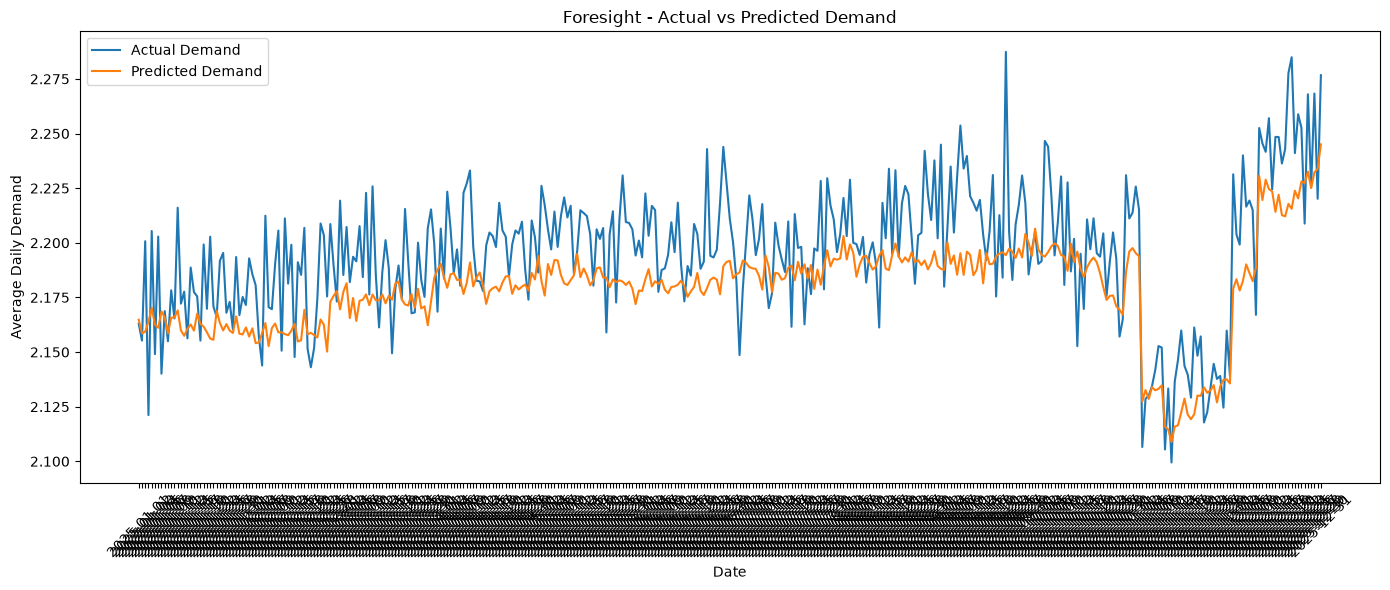

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))

plt.plot(
    daily_forecast["date"],
    daily_forecast["actual_quantity"],
    label="Actual Demand"
)

plt.plot(
    daily_forecast["date"],
    daily_forecast["predicted_quantity"],
    label="Predicted Demand"
)

plt.xlabel("Date")
plt.ylabel("Average Daily Demand")
plt.title("Foresight - Actual vs Predicted Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [42]:
forecast_results["date"]=pd.to_datetime(forecast_results["date"])

In [43]:
# convert the graph from year to month for better understanding
monthly_forecast=(
    forecast_results
    .assign(month=forecast_results["date"].dt.to_period("M"))
    .groupby("month")[["actual_quantity","predicted_quantity"]]
    .mean()
    .reset_index()
)
monthly_forecast["month"]=monthly_forecast["month"].astype(str)

print("Monthly forecast shape: ",monthly_forecast.shape)
monthly_forecast.head()

Monthly forecast shape:  (12, 3)


,month,actual_quantity,predicted_quantity
0,2025-01,2.174736,2.162453
1,2025-02,2.178631,2.158807
2,2025-03,2.190072,2.173676
3,2025-04,2.200558,2.181647
4,2025-05,2.203805,2.184652


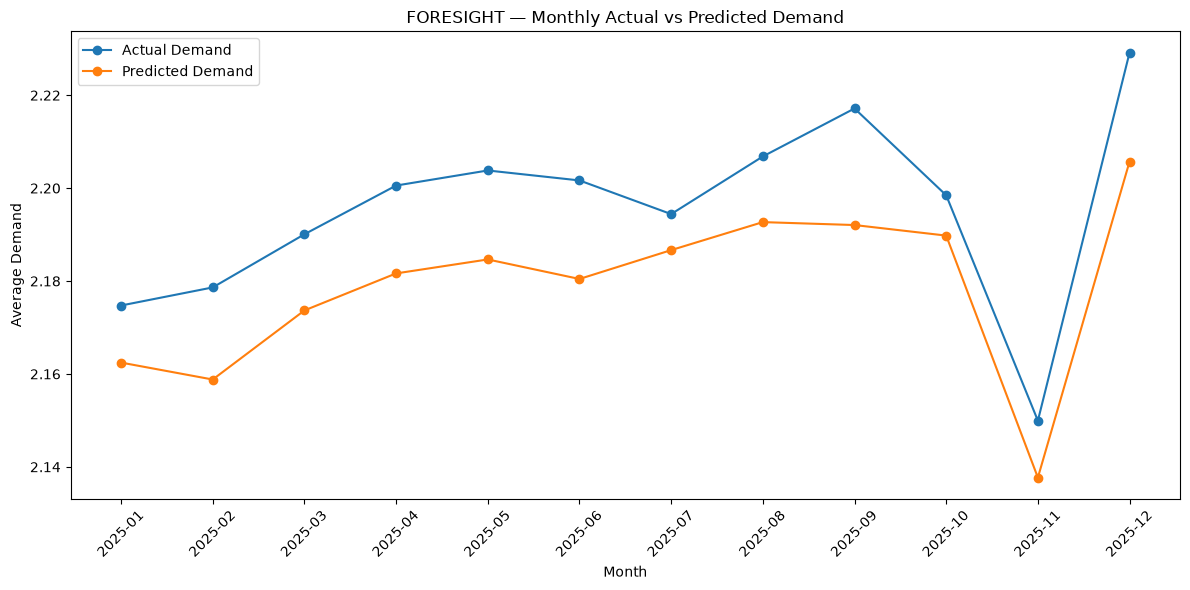

In [44]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast["month"],
    monthly_forecast["actual_quantity"],
    marker="o",
    label="Actual Demand"
)  # Plot actual monthly average demand

plt.plot(
    monthly_forecast["month"],
    monthly_forecast["predicted_quantity"],
    marker="o",
    label="Predicted Demand"
)  # Plot LightGBM predicted monthly average demand

plt.xlabel("Month")
plt.ylabel("Average Demand")
plt.title("FORESIGHT — Monthly Actual vs Predicted Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [45]:
forecast_results.to_csv(
    "../data/processed/forecast_results.csv",
    index=False
)

print("Forecast results saved successfully.")
print("Shape:", forecast_results.shape)

Forecast results saved successfully.
Shape: (2267573, 5)
